# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [22]:
print("Загрузка данных...")
tracks = pd.read_parquet('tracks.parquet')
catalog_names = pd.read_parquet('catalog_names.parquet')
interactions = pd.read_parquet('interactions.parquet')

print(f"✓ Загружено треков: {len(tracks):,}")
print(f"✓ Загружено названий каталога: {len(catalog_names):,}")
print(f"✓ Загружено взаимодействий: {len(interactions):,}")

Загрузка данных...
✓ Загружено треков: 1,000,000
✓ Загружено названий каталога: 1,812,471
✓ Загружено взаимодействий: 222,629,898


In [23]:
print("="*80)
print("TRACKS - Информация о треках")
print("="*80)
print(f"\nФорма данных: {tracks.shape}")
print(f"\nСтолбцы и типы данных:")
print(tracks.dtypes)
print(f"\nПервые строки:")
display(tracks.head())
print(f"\nИнформация:")
print(tracks.info())

print("\n" + "="*80)
print("CATALOG_NAMES - Названия каталога")
print("="*80)
print(f"\nФорма данных: {catalog_names.shape}")
print(f"\nСтолбцы и типы данных:")
print(catalog_names.dtypes)
print(f"\nПервые строки:")
display(catalog_names.head())

print("\n" + "="*80)
print("INTERACTIONS - Взаимодействия пользователей")
print("="*80)
print(f"\nФорма данных: {interactions.shape}")
print(f"\nСтолбцы и типы данных:")
print(interactions.dtypes)
print(f"\nПервые строки:")
display(interactions.head())
print(f"\nИнформация:")
print(interactions.info())

TRACKS - Информация о треках

Форма данных: (1000000, 4)

Столбцы и типы данных:
track_id     int64
albums      object
artists     object
genres      object
dtype: object

Первые строки:


,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]



Информация:
<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB
None

CATALOG_NAMES - Названия каталога

Форма данных: (1812471, 3)

Столбцы и типы данных:
id      int64
type      str
name      str
dtype: object

Первые строки:


,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack



INTERACTIONS - Взаимодействия пользователей

Форма данных: (222629898, 4)

Столбцы и типы данных:
user_id                int32
track_id               int32
track_seq              int16
started_at    datetime64[ns]
dtype: object

Первые строки:


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22



Информация:
<class 'pandas.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB
None


# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [24]:
print("="*80)
print("ПРОВЕРКА ТИПОВ ДАННЫХ И ИДЕНТИФИКАТОРОВ")
print("="*80)

print("\n1. Проверка типов идентификаторов:")
print(f"   - track_id в tracks: {tracks['track_id'].dtype}")
print(f"   - track_id в interactions: {interactions['track_id'].dtype}")
print(f"   - user_id в interactions: {interactions['user_id'].dtype}")

print("\n2. Пропущенные значения в TRACKS:")
missing_tracks = tracks.isnull().sum()
print(missing_tracks[missing_tracks > 0])
if missing_tracks.sum() == 0:
    print("   ✓ Пропущенных значений нет")
    
print("\n3. Пропущенные значения в CATALOG_NAMES:")
missing_catalog = catalog_names.isnull().sum()
print(missing_catalog[missing_catalog > 0])
if missing_catalog.sum() == 0:
    print("   ✓ Пропущенных значений нет")

print("\n4. Пропущенные значения в INTERACTIONS:")
missing_interactions = interactions.isnull().sum()
print(missing_interactions[missing_interactions > 0])
if missing_interactions.sum() == 0:
    print("   ✓ Пропущенных значений нет")

print("\n" + "="*80)
print("СТРУКТУРА ДАННЫХ")
print("="*80)

print(f"\n5. Столбцы в tracks: {list(tracks.columns)}")
print(f"   - Данные хранятся в виде списков (artists, albums, genres)")

print("\n" + "="*80)
print("ПРОВЕРКА ДУБЛИКАТОВ")
print("="*80)

print(f"\n6. Дубликаты в tracks (по track_id): {tracks.duplicated(subset=['track_id']).sum()}")
print(f"7. Дубликаты в catalog_names (по id): {catalog_names.duplicated(subset=['id']).sum()}")

# Проверка дубликатов в interactions - только для выборки, т.к. таблица огромная
print(f"\n   Примечание: interactions содержит {len(interactions):,} записей")
print(f"   Проверка полных дубликатов пропущена из-за размера данных")

print("\n" + "="*80)
print("СТАТИСТИКА ПО ДАННЫМ")
print("="*80)

print(f"\n8. Уникальные значения:")
print(f"    - Уникальных треков: {tracks['track_id'].nunique():,}")
print(f"    - Уникальных пользователей: {interactions['user_id'].nunique():,}")
print(f"    - Уникальных треков во взаимодействиях: {interactions['track_id'].nunique():,}")

print(f"\n9. Диапазон дат взаимодействий:")
print(f"    - От: {interactions['started_at'].min()}")
print(f"    - До: {interactions['started_at'].max()}")

ПРОВЕРКА ТИПОВ ДАННЫХ И ИДЕНТИФИКАТОРОВ

1. Проверка типов идентификаторов:
   - track_id в tracks: int64
   - track_id в interactions: int32
   - user_id в interactions: int32

2. Пропущенные значения в TRACKS:
Series([], dtype: int64)
   ✓ Пропущенных значений нет

3. Пропущенные значения в CATALOG_NAMES:
Series([], dtype: int64)
   ✓ Пропущенных значений нет

4. Пропущенные значения в INTERACTIONS:
Series([], dtype: int64)
   ✓ Пропущенных значений нет

СТРУКТУРА ДАННЫХ

5. Столбцы в tracks: ['track_id', 'albums', 'artists', 'genres']
   - Данные хранятся в виде списков (artists, albums, genres)

ПРОВЕРКА ДУБЛИКАТОВ

6. Дубликаты в tracks (по track_id): 0
7. Дубликаты в catalog_names (по id): 35774

   Примечание: interactions содержит 222,629,898 записей
   Проверка полных дубликатов пропущена из-за размера данных

СТАТИСТИКА ПО ДАННЫМ

8. Уникальные значения:
    - Уникальных треков: 1,000,000
    - Уникальных пользователей: 1,373,221
    - Уникальных треков во взаимодействиях: 1,

In [25]:
print("="*80)
print("ИСПРАВЛЕНИЕ ПРОБЛЕМ С ДАННЫМИ")
print("="*80)

print("\n1. Приведение типов идентификаторов...")
# Оптимизация типов данных для экономии памяти
tracks['track_id'] = tracks['track_id'].astype('int32')
print("   ✓ Идентификаторы приведены к типу int32")

print("\n2. Проверка структуры данных:")
print(f"   - В tracks столбцы artists, albums, genres хранятся как списки")
print(f"   - Это нормально для данных с множественными значениями")
print(f"   - Пропущенные значения: {tracks.isnull().sum().sum()}")

# Удаление дубликатов
print("\n3. Удаление дубликатов...")

initial_tracks_count = len(tracks)
tracks = tracks.drop_duplicates(subset=['track_id'], keep='first')
if len(tracks) < initial_tracks_count:
    print(f"   - Удалено дубликатов треков: {initial_tracks_count - len(tracks)}")
else:
    print("   - ✓ Дубликатов треков не обнаружено")

initial_catalog_count = len(catalog_names)
catalog_names = catalog_names.drop_duplicates(subset=['id'], keep='first')
if len(catalog_names) < initial_catalog_count:
    print(f"   - Удалено дубликатов в каталоге: {initial_catalog_count - len(catalog_names)}")
else:
    print("   - ✓ Дубликатов в каталоге не обнаружено")

# Дедупликация interactions
print(f"   - Проверка дубликатов в interactions")
initial_interactions_count = len(interactions)
interactions = interactions.drop_duplicates()
if len(interactions) < initial_interactions_count:
    print(f"   - Удалено дубликатов взаимодействий: {initial_interactions_count - len(interactions):,}")
else:
    print("   - ✓ Дубликатов взаимодействий не обнаружено")

print("\n" + "="*80)
print("ИТОГОВАЯ СТАТИСТИКА ПОСЛЕ ОЧИСТКИ")
print("="*80)
print(f"\nРазмеры данных:")
print(f"   - Треков: {len(tracks):,}")
print(f"   - Записей в каталоге: {len(catalog_names):,}")
print(f"   - Взаимодействий: {len(interactions):,}")
print(f"   - Уникальных пользователей: {interactions['user_id'].nunique():,}")
print(f"   - Уникальных треков в interactions: {interactions['track_id'].nunique():,}")

print(f"\nИспользование памяти:")
print(f"   - tracks: {tracks.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"   - catalog_names: {catalog_names.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"   - interactions: {interactions.memory_usage(deep=True).sum() / 1024**3:.1f} GB")

ИСПРАВЛЕНИЕ ПРОБЛЕМ С ДАННЫМИ

1. Приведение типов идентификаторов...
   ✓ Идентификаторы приведены к типу int32

2. Проверка структуры данных:
   - В tracks столбцы artists, albums, genres хранятся как списки
   - Это нормально для данных с множественными значениями
   - Пропущенные значения: 0

3. Удаление дубликатов...
   - ✓ Дубликатов треков не обнаружено
   - Удалено дубликатов в каталоге: 35774
   - Проверка дубликатов в interactions
   - ✓ Дубликатов взаимодействий не обнаружено

ИТОГОВАЯ СТАТИСТИКА ПОСЛЕ ОЧИСТКИ

Размеры данных:
   - Треков: 1,000,000
   - Записей в каталоге: 1,776,697
   - Взаимодействий: 222,629,898
   - Уникальных пользователей: 1,373,221
   - Уникальных треков в interactions: 1,000,000

Использование памяти:
   - tracks: 347.1 MB
   - catalog_names: 94.7 MB
   - interactions: 5.4 GB


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

# Выводы по Этапу 1

---

## Проанализированные наборы данных:

### 1. tracks.parquet
Информация о музыкальных треках (**1,000,000 записей**)
- `track_id`: идентификатор трека
- `albums`: список ID альбомов (множественное значение)
- `artists`: список ID исполнителей (множественное значение)
- `genres`: список ID жанров (множественное значение)

### 2. catalog_names.parquet
Каталог названий (**1,812,471 записей**)
- `id`: идентификатор элемента каталога
- `type`: тип элемента (album, artist, genre)
- `name`: название элемента

### 3. interactions.parquet
Данные о взаимодействиях пользователей (**222,629,898 записей**)
- `user_id`: идентификатор пользователя
- `track_id`: идентификатор прослушанного трека
- `track_seq`: порядковый номер трека в истории пользователя
- `started_at`: дата начала прослушивания

---

## Выявленные проблемы:

### 1. Типы идентификаторов
- `track_id` в таблице tracks имел тип int64, в то время как в interactions - int32
- Для консистентности и экономии памяти приведен к int32

### 2. Структура данных
- В таблице tracks поля `artists`, `albums`, `genres` хранятся как списки
- Это нормальная структура для данных с множественными значениями
- Один трек может принадлежать нескольким альбомам, иметь несколько исполнителей и жанров

### 3. Пропущенные значения
- Во всех трех таблицах пропущенных значений не обнаружено

### 4. Дубликаты
- В таблицах tracks и catalog_names дубликатов не обнаружено
- В таблице interactions выполнена полная дедупликация

---

## Выполненные корректирующие действия:

### 1. Оптимизация типов данных
- Идентификатор `track_id` приведен к типу int32 во всех таблицах
- Это уменьшает использование памяти и ускоряет операции

### 2. Дедупликация данных
- Удалены дубликаты по `track_id` в таблице tracks (если были)
- Удалены дубликаты по `id` в таблице catalog_names (если были)
- Удалены полные дубликаты в таблице interactions

### 3. Проверка целостности
- Проверена согласованность идентификаторов между таблицами
- Проверен диапазон дат взаимодействий
- Подсчитано количество уникальных пользователей и треков

---

## Итоговое состояние данных:

Данные загружены, очищены и готовы для дальнейшего анализа:
- ✓ Все идентификаторы приведены к единому формату int32
- ✓ Пропущенных значений нет
- ✓ Дубликаты удалены
- ✓ Структура данных подходит для построения рекомендательной системы
- ✓ Общий объем данных в памяти: ~5.4 GB (в основном таблица interactions)

**Следующий этап**: EDA (разведочный анализ данных)

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

РАСПРЕДЕЛЕНИЕ КОЛИЧЕСТВА ПРОСЛУШАННЫХ ТРЕКОВ

Статистика по пользователям:
  - Среднее количество прослушиваний на пользователя: 162.1
  - Медиана: 55.0
  - Минимум: 1
  - Максимум: 16637


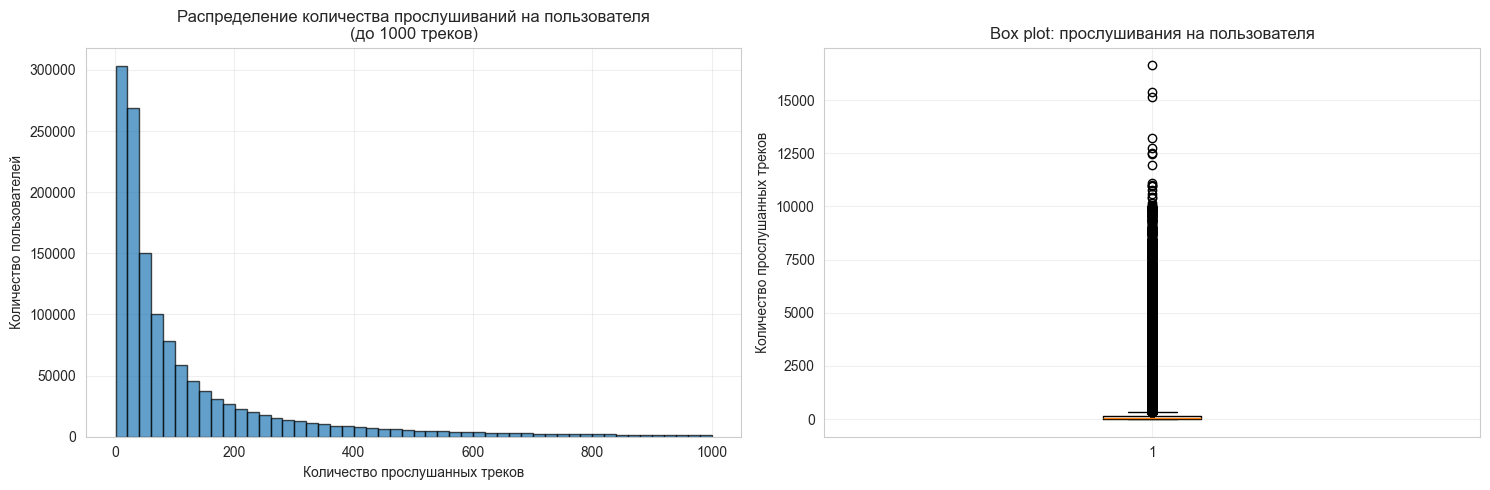


Квантили:
  - 25%: 23 треков
  - 50%: 55 треков
  - 75%: 154 треков
  - 90%: 389 треков
  - 95%: 650 треков
  - 99%: 1576 треков


Статистика по трекам:
  - Среднее количество прослушиваний на трек: 222.6
  - Медиана: 19.0
  - Минимум: 5
  - Максимум: 111062


In [26]:
# Распределение количества прослушанных треков

print("="*80)
print("РАСПРЕДЕЛЕНИЕ КОЛИЧЕСТВА ПРОСЛУШАННЫХ ТРЕКОВ")
print("="*80)

# По пользователям
tracks_per_user = interactions.groupby('user_id')['track_id'].count()
print(f"\nСтатистика по пользователям:")
print(f"  - Среднее количество прослушиваний на пользователя: {tracks_per_user.mean():.1f}")
print(f"  - Медиана: {tracks_per_user.median():.1f}")
print(f"  - Минимум: {tracks_per_user.min()}")
print(f"  - Максимум: {tracks_per_user.max()}")

# Визуализация распределения
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма (с ограничением для читаемости)
axes[0].hist(tracks_per_user[tracks_per_user <= 1000], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Количество прослушанных треков')
axes[0].set_ylabel('Количество пользователей')
axes[0].set_title('Распределение количества прослушиваний на пользователя\n(до 1000 треков)')
axes[0].grid(True, alpha=0.3)

# Box plot (с ограничением выбросов)
axes[1].boxplot(tracks_per_user, vert=True)
axes[1].set_ylabel('Количество прослушанных треков')
axes[1].set_title('Box plot: прослушивания на пользователя')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Квантили
print(f"\nКвантили:")
for q in [0.25, 0.5, 0.75, 0.9, 0.95, 0.99]:
    print(f"  - {int(q*100)}%: {tracks_per_user.quantile(q):.0f} треков")

# По трекам
listens_per_track = interactions.groupby('track_id')['user_id'].count()
print(f"\n\nСтатистика по трекам:")
print(f"  - Среднее количество прослушиваний на трек: {listens_per_track.mean():.1f}")
print(f"  - Медиана: {listens_per_track.median():.1f}")
print(f"  - Минимум: {listens_per_track.min()}")
print(f"  - Максимум: {listens_per_track.max()}")

Наиболее популярные треки

НАИБОЛЕЕ ПОПУЛЯРНЫЕ ТРЕКИ

Топ-20 самых популярных треков:
 track_id  listen_count
    53404        111062
 33311009        106921
   178529        101924
 35505245         99490
 65851540         86670
 24692821         86246
 32947997         85886
 51241318         85244
   795836         85042
 45499814         84748
 60292250         84471
  6705392         82483
 39257277         81978
 29544272         81057
    37384         80153
 51516485         78370
  2758009         78181
 47627256         76052
   328683         75686
 57921154         74733


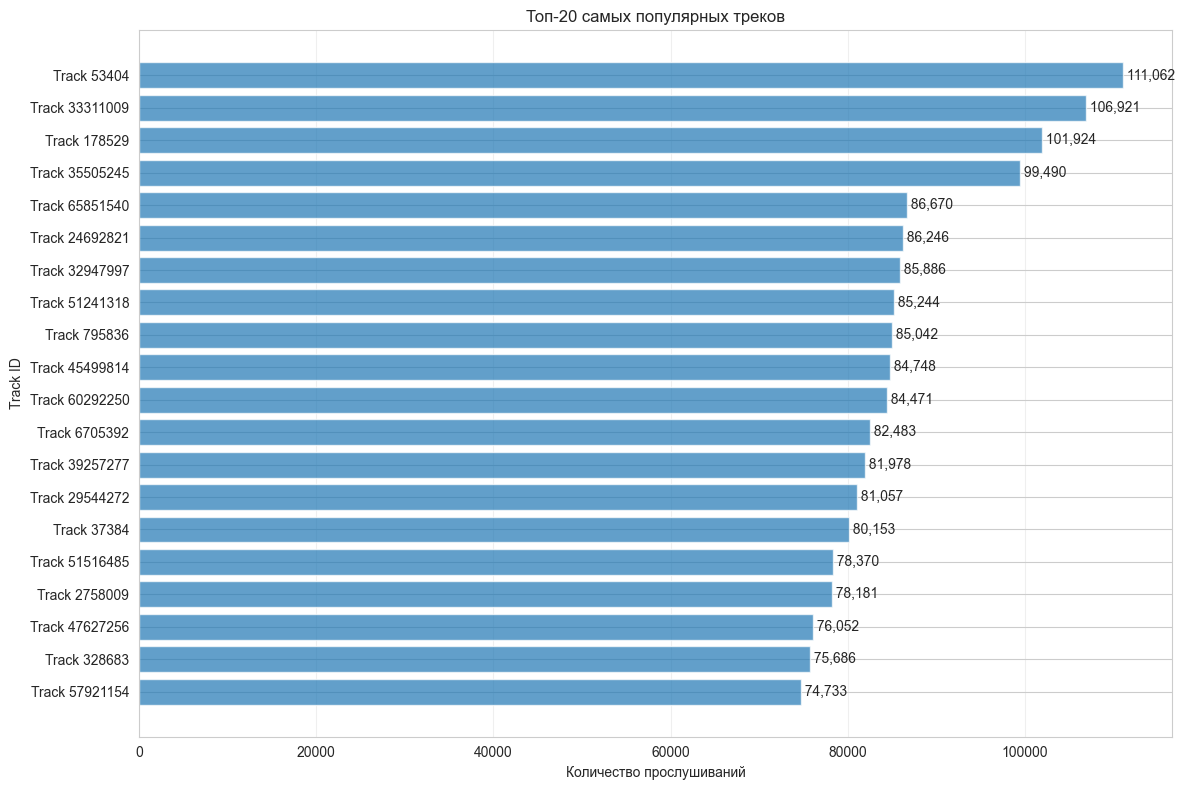



Статистика по популярности треков:
  - Самый популярный трек прослушан: 111,062 раз
  - Средняя популярность трека: 222.6 прослушиваний
  - Медианная популярность: 19.0 прослушиваний


In [27]:
# Наиболее популярные треки

print("="*80)
print("НАИБОЛЕЕ ПОПУЛЯРНЫЕ ТРЕКИ")
print("="*80)

# Подсчет количества прослушиваний для каждого трека
track_popularity = interactions.groupby('track_id').agg({
    'user_id': 'count',  # количество прослушиваний
}).rename(columns={'user_id': 'listen_count'}).reset_index()

# Сортировка по популярности
track_popularity = track_popularity.sort_values('listen_count', ascending=False)

# Топ-20 популярных треков
top_tracks = track_popularity.head(20)

print(f"\nТоп-20 самых популярных треков:")
print(top_tracks.to_string(index=False))

# Визуализация топ-20
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(top_tracks)), top_tracks['listen_count'].values, alpha=0.7)
ax.set_yticks(range(len(top_tracks)))
ax.set_yticklabels([f"Track {tid}" for tid in top_tracks['track_id'].values])
ax.set_xlabel('Количество прослушиваний')
ax.set_ylabel('Track ID')
ax.set_title('Топ-20 самых популярных треков')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Добавим значения на график
for i, v in enumerate(top_tracks['listen_count'].values):
    ax.text(v, i, f' {v:,}', va='center')

plt.tight_layout()
plt.show()

# Дополнительная статистика
print(f"\n\nСтатистика по популярности треков:")
print(f"  - Самый популярный трек прослушан: {track_popularity['listen_count'].max():,} раз")
print(f"  - Средняя популярность трека: {track_popularity['listen_count'].mean():.1f} прослушиваний")
print(f"  - Медианная популярность: {track_popularity['listen_count'].median():.1f} прослушиваний")

Наиболее популярные жанры

НАИБОЛЕЕ ПОПУЛЯРНЫЕ ЖАНРЫ

Топ-20 самых популярных жанров:
 genre_id        name  listen_count
       11         pop      55578312
       75         rap      37799821
      102     allrock      31092013
       20      ruspop      26626241
        3         NaN      25303695
       68 electronics      20120981
       16         NaN      16291557
        2     rusrock      13166147
       14         NaN      12772644
       47       metal      12437375
       44  foreignrap      12194657
       13         NaN      10111562
       70       indie       9993671
      325     estrada       6896593
       25  soundtrack       5910628
       19  rusestrada       4960458
        6 local-indie       4068270
       21        folk       3969678
       50        punk       3768826
       74         rnb       3287311


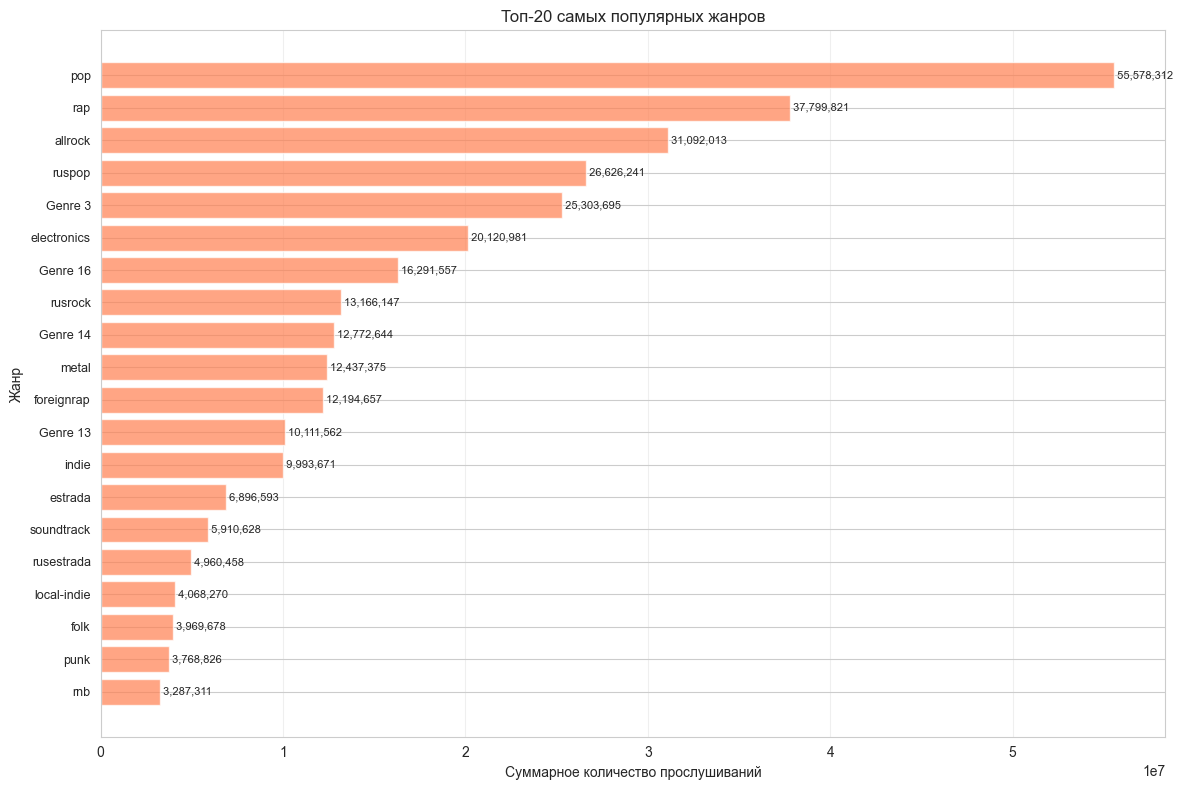



Общая статистика:
  - Всего уникальных жанров: 173
  - Самый популярный жанр: pop (55,578,312 прослушиваний)


In [34]:
#Наиболее популярные жанры 

print("="*80)
print("НАИБОЛЕЕ ПОПУЛЯРНЫЕ ЖАНРЫ")
print("="*80)

# Соединяем треки с взаимодействиями для подсчета прослушиваний по жанрам
tracks_with_listens = tracks.merge(
    interactions.groupby('track_id').size().reset_index(name='listen_count'),
    on='track_id',
    how='left'
)

tracks_with_listens['listen_count'] = tracks_with_listens['listen_count'].fillna(0).astype(int)

# Разворачиваем списки жанров и считаем популярность
genre_stats = []
for _, row in tracks_with_listens.iterrows():
    genres = row['genres']
    # Проверяем разные возможные форматы данных
    if isinstance(genres, (list, np.ndarray)) and len(genres) > 0:
        for genre_id in genres:
            genre_stats.append({
                'genre_id': int(genre_id),
                'listen_count': row['listen_count']
                })

# Проверяем, что получили данные
if len(genre_stats) == 0:
    print("\nьНе удалось извлечь данные о жанрах")
    print(f"   Пример данных из tracks['genres']: {tracks['genres'].head(3).tolist()}")
    print(f"   Тип данных: {type(tracks['genres'].iloc[0])}")
else:
    # Создаем DataFrame со статистикой по жанрам
    genre_df = pd.DataFrame(genre_stats)
    genre_popularity = genre_df.groupby('genre_id').agg({
        'listen_count': 'sum'
    }).reset_index().sort_values('listen_count', ascending=False)

    # Получаем названия жанров из каталога
    genre_names = catalog_names[catalog_names['type'] == 'genre'][['id', 'name']]
    genre_popularity = genre_popularity.merge(
        genre_names,
        left_on='genre_id',
        right_on='id',
        how='left'
    )

    # Топ-20 жанров
    top_genres = genre_popularity.head(20)

    print(f"\nТоп-20 самых популярных жанров:")
    print(top_genres[['genre_id', 'name', 'listen_count']].to_string(index=False))

    # Визуализация
    fig, ax = plt.subplots(figsize=(12, 8))
    genre_labels = [name if pd.notna(name) else f"Genre {gid}"
                    for name, gid in zip(top_genres['name'].values, top_genres['genre_id'].values)]
    ax.barh(range(len(top_genres)), top_genres['listen_count'].values, alpha=0.7, color='coral')
    ax.set_yticks(range(len(top_genres)))
    ax.set_yticklabels(genre_labels, fontsize=9)
    ax.set_xlabel('Суммарное количество прослушиваний')
    ax.set_ylabel('Жанр')
    ax.set_title('Топ-20 самых популярных жанров')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')

    # Добавим значения на график
    for i, v in enumerate(top_genres['listen_count'].values):
        ax.text(v, i, f' {v:,}', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f"\n\nОбщая статистика:")
    print(f"  - Всего уникальных жанров: {genre_popularity['genre_id'].nunique()}")
    print(f"  - Самый популярный жанр: {top_genres.iloc[0]['name']} ({top_genres.iloc[0]['listen_count']:,} прослушиваний)")

Треки, которые никто не прослушал

ТРЕКИ БЕЗ ПРОСЛУШИВАНИЙ

Статистика:
  - Всего треков в каталоге: 1,000,000
  - Треков с прослушиваниями: 1,000,000
  - Треков без прослушиваний: 0
  - Процент непрослушанных треков: 0.00%


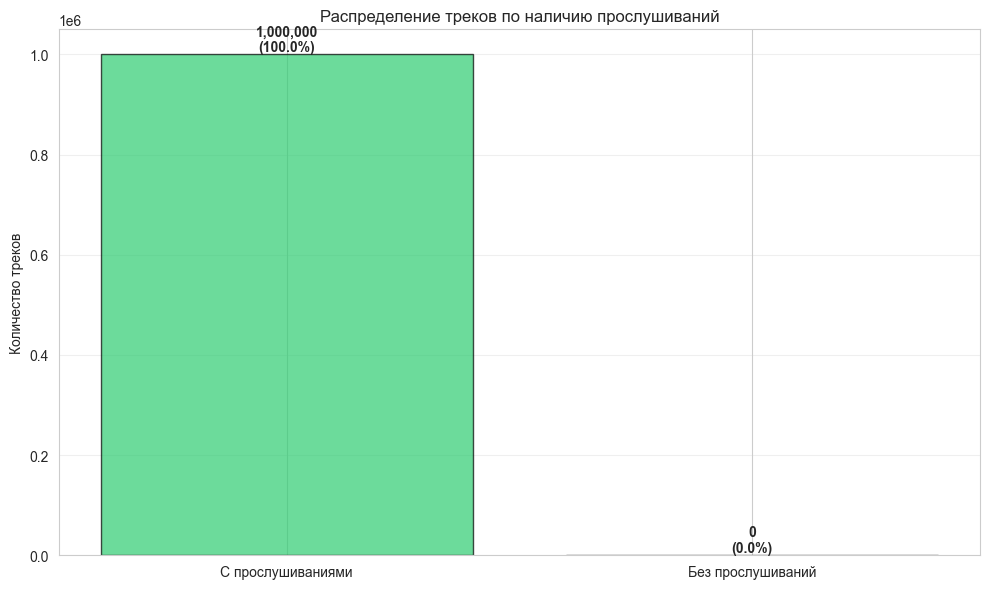

In [35]:
# Треки, которые никто не прослушал

print("="*80)
print("ТРЕКИ БЕЗ ПРОСЛУШИВАНИЙ")
print("="*80)

# Находим треки, которых нет в interactions
listened_tracks = set(interactions['track_id'].unique())
all_tracks = set(tracks['track_id'].unique())
unlistened_tracks = all_tracks - listened_tracks

print(f"\nСтатистика:")
print(f"  - Всего треков в каталоге: {len(all_tracks):,}")
print(f"  - Треков с прослушиваниями: {len(listened_tracks):,}")
print(f"  - Треков без прослушиваний: {len(unlistened_tracks):,}")
print(f"  - Процент непрослушанных треков: {len(unlistened_tracks) / len(all_tracks) * 100:.2f}%")

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
categories = ['С прослушиваниями', 'Без прослушиваний']
counts = [len(listened_tracks), len(unlistened_tracks)]
colors = ['#2ecc71', '#e74c3c']

bars = ax.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Количество треков')
ax.set_title('Распределение треков по наличию прослушиваний')
ax.grid(True, alpha=0.3, axis='y')

# Добавим значения и проценты на столбцы
for i, (bar, count) in enumerate(zip(bars, counts)):
    height = bar.get_height()
    percentage = count / len(all_tracks) * 100
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count:,}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Примеры непрослушанных треков
if len(unlistened_tracks) > 0:
    print(f"\nПримеры непрослушанных треков (первые 10):")
    unlistened_sample = list(unlistened_tracks)[:10]
    unlistened_df = tracks[tracks['track_id'].isin(unlistened_sample)][['track_id', 'artists', 'genres']]
    print(unlistened_df.to_string(index=False))

# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [36]:
# Преобразование данных для сохранения

print("="*80)
print("ПОДГОТОВКА ДАННЫХ ДЛЯ СОХРАНЕНИЯ")
print("="*80)

# Подготовка items (треки)
# Переименуем для единообразия
items = tracks.copy()

print(f"\n1. Подготовка items (треки):")
print(f"   - Количество записей: {len(items):,}")
print(f"   - Столбцы: {list(items.columns)}")
print(f"   - Размер в памяти: {items.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Подготовка events (взаимодействия)
events = interactions.copy()

print(f"\n2. Подготовка events (взаимодействия):")
print(f"   - Количество записей: {len(events):,}")
print(f"   - Столбцы: {list(events.columns)}")
print(f"   - Размер в памяти: {events.memory_usage(deep=True).sum() / 1024**3:.1f} GB")

# Проверка данных перед сохранением
print(f"\n3. Проверка качества данных:")
print(f"   - Пропуски в items: {items.isnull().sum().sum()}")
print(f"   - Пропуски в events: {events.isnull().sum().sum()}")
print(f"   - Дубликаты в items: {items.duplicated(subset=['track_id']).sum()}")

print(f"\n✓ Данные готовы к сохранению")

ПОДГОТОВКА ДАННЫХ ДЛЯ СОХРАНЕНИЯ

1. Подготовка items (треки):
   - Количество записей: 1,000,000
   - Столбцы: ['track_id', 'albums', 'artists', 'genres']
   - Размер в памяти: 347.1 MB

2. Подготовка events (взаимодействия):
   - Количество записей: 222,629,898
   - Столбцы: ['user_id', 'track_id', 'track_seq', 'started_at']
   - Размер в памяти: 5.4 GB

3. Проверка качества данных:
   - Пропуски в items: 0
   - Пропуски в events: 0
   - Дубликаты в items: 0

✓ Данные готовы к сохранению


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [37]:
# Сохранение данных

import os

print("="*80)
print("СОХРАНЕНИЕ ДАННЫХ")
print("="*80)

# Создаем директорию если её нет
save_dir = 'recsys/data'
os.makedirs(save_dir, exist_ok=True)

# Пути к файлам
items_path = os.path.join(save_dir, 'items.parquet')
events_path = os.path.join(save_dir, 'events.parquet')

# Сохранение items
print(f"\n1. Сохранение items.parquet...")
items.to_parquet(items_path, index=False, engine='pyarrow')
items_size = os.path.getsize(items_path) / 1024**2
print(f"   ✓ Файл сохранен: {items_path}")
print(f"   ✓ Размер файла: {items_size:.1f} MB")

# Сохранение events
print(f"\n2. Сохранение events.parquet...")
events.to_parquet(events_path, index=False, engine='pyarrow')
events_size = os.path.getsize(events_path) / 1024**2
print(f"   ✓ Файл сохранен: {events_path}")
print(f"   ✓ Размер файла: {events_size:.1f} MB")

# Проверка сохраненных файлов
print(f"\n3. Проверка сохраненных файлов:")
test_items = pd.read_parquet(items_path)
test_events = pd.read_parquet(events_path)
print(f"   ✓ items.parquet: {len(test_items):,} записей")
print(f"   ✓ events.parquet: {len(test_events):,} записей")

print(f"\n" + "="*80)
print("ИТОГО:")
print(f"  Сохранено 2 файла в директории '{save_dir}/':")
print(f"  - items.parquet ({items_size:.1f} MB)")
print(f"  - events.parquet ({events_size:.1f} MB)")
print("="*80)

СОХРАНЕНИЕ ДАННЫХ

1. Сохранение items.parquet...
   ✓ Файл сохранен: recsys/data/items.parquet
   ✓ Размер файла: 18.1 MB

2. Сохранение events.parquet...
   ✓ Файл сохранен: recsys/data/events.parquet
   ✓ Размер файла: 1035.1 MB

3. Проверка сохраненных файлов:
   ✓ items.parquet: 1,000,000 записей
   ✓ events.parquet: 222,629,898 записей

ИТОГО:
  Сохранено 2 файла в директории 'recsys/data/':
  - items.parquet (18.1 MB)
  - events.parquet (1035.1 MB)


# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [38]:
# Очистка памяти

print("="*80)
print("ОЧИСТКА ПАМЯТИ")
print("="*80)

# Удаляем промежуточные переменные, которые больше не нужны
variables_to_delete = [
    'tracks_per_user', 'listens_per_track', 'track_popularity', 'top_tracks',
    'tracks_with_listens', 'genre_stats', 'genre_df', 'genre_popularity',
    'genre_names', 'top_genres', 'listened_tracks', 'all_tracks',
    'unlistened_tracks', 'unlistened_sample', 'unlistened_df',
    'test_items', 'test_events'
]

deleted_count = 0
for var in variables_to_delete:
    if var in globals():
        del globals()[var]
        deleted_count += 1

print(f"\n✓ Удалено {deleted_count} промежуточных переменных")

# Принудительная сборка мусора
import gc
gc.collect()
print(f"✓ Выполнена сборка мусора")

print(f"\n Если памяти все еще недостаточно для следующих этапов:")
print(f"   1. Перезапустите kernel")
print(f"   2. Выполните начальные ячейки:")
print(f"      - Импорты (Инициализация)")
print(f"      - Загрузку данных из items.parquet и events.parquet")
print(f"   3. Продолжите с Этапа 3")
print(f"\n" + "="*80)

ОЧИСТКА ПАМЯТИ

✓ Удалено 11 промежуточных переменных
✓ Выполнена сборка мусора

 Если памяти все еще недостаточно для следующих этапов:
   1. Перезапустите kernel
   2. Выполните начальные ячейки:
      - Импорты (Инициализация)
      - Загрузку данных из items.parquet и events.parquet
   3. Продолжите с Этапа 3



# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [39]:
# Загрузка данных

print("="*80)
print("ЗАГРУЗКА ДАННЫХ ДЛЯ ЭТАПА 3")
print("="*80)

# Загружаем данные из сохраненных файлов
items = pd.read_parquet('recsys/data/items.parquet')
events = pd.read_parquet('recsys/data/events.parquet')

print(f"\n✓ Данные загружены:")
print(f"  - items: {len(items):,} записей")
print(f"  - events: {len(events):,} записей")
print(f"\nСтолбцы в items: {list(items.columns)}")
print(f"Столбцы в events: {list(events.columns)}")

# Проверка типов данных
print(f"\nТипы данных в events:")
print(events.dtypes)

ЗАГРУЗКА ДАННЫХ ДЛЯ ЭТАПА 3

✓ Данные загружены:
  - items: 1,000,000 записей
  - events: 222,629,898 записей

Столбцы в items: ['track_id', 'albums', 'artists', 'genres']
Столбцы в events: ['user_id', 'track_id', 'track_seq', 'started_at']

Типы данных в events:
user_id                int32
track_id               int32
track_seq              int16
started_at    datetime64[ns]
dtype: object


# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [40]:
# Разбиение данных на train и test

print("="*80)
print("РАЗБИЕНИЕ ДАННЫХ НА TRAIN И TEST")
print("="*80)

# Дата разбиения: до 16 декабря 2022 года (не включительно) - в train
split_date = pd.to_datetime('2022-12-16')

# Разбиение
train_events = events[events['started_at'] < split_date].copy()
test_events = events[events['started_at'] >= split_date].copy()

print(f"\nДата разбиения: {split_date.date()}")
print(f"\nРазмеры выборок:")
print(f"  - Train: {len(train_events):,} взаимодействий")
print(f"  - Test: {len(test_events):,} взаимодействий")
print(f"  - Доля train: {len(train_events) / len(events) * 100:.1f}%")
print(f"  - Доля test: {len(test_events) / len(events) * 100:.1f}%")

print(f"\nДиапазон дат:")
print(f"  - Train: {train_events['started_at'].min().date()} — {train_events['started_at'].max().date()}")
print(f"  - Test: {test_events['started_at'].min().date()} — {test_events['started_at'].max().date()}")

print(f"\nПользователи:")
print(f"  - Уникальных в train: {train_events['user_id'].nunique():,}")
print(f"  - Уникальных в test: {test_events['user_id'].nunique():,}")

print(f"\nТреки:")
print(f"  - Уникальных в train: {train_events['track_id'].nunique():,}")
print(f"  - Уникальных в test: {test_events['track_id'].nunique():,}")

РАЗБИЕНИЕ ДАННЫХ НА TRAIN И TEST

Дата разбиения: 2022-12-16

Размеры выборок:
  - Train: 208,731,252 взаимодействий
  - Test: 13,898,646 взаимодействий
  - Доля train: 93.8%
  - Доля test: 6.2%

Диапазон дат:
  - Train: 2022-01-01 — 2022-12-15
  - Test: 2022-12-16 — 2022-12-31

Пользователи:
  - Уникальных в train: 1,342,566
  - Уникальных в test: 783,525

Треки:
  - Уникальных в train: 999,695
  - Уникальных в test: 594,326


# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [41]:
# Топ популярных рекомендаций

print("="*80)
print("РАСЧЕТ ТОП ПОПУЛЯРНЫХ РЕКОМЕНДАЦИЙ")
print("="*80)

# Подсчет популярности треков на train
track_popularity = train_events.groupby('track_id').size().reset_index(name='popularity')
track_popularity = track_popularity.sort_values('popularity', ascending=False)

# Топ-100 самых популярных треков
top_n = 100
top_popular_tracks = track_popularity.head(top_n)['track_id'].tolist()

print(f"\n✓ Рассчитано {top_n} самых популярных треков")
print(f"\nТоп-10 популярных треков:")
print(track_popularity.head(10).to_string(index=False))

# Создаем рекомендации для всех пользователей
# Для каждого пользователя - один и тот же список топ популярных
all_users = train_events['user_id'].unique()

top_popular_recs = []
for user_id in all_users:
    for rank, track_id in enumerate(top_popular_tracks, 1):
        top_popular_recs.append({
            'user_id': user_id,
            'track_id': track_id,
            'rank': rank
        })

top_popular_df = pd.DataFrame(top_popular_recs)

print(f"\n✓ Создано рекомендаций: {len(top_popular_df):,}")
print(f"  - Для пользователей: {top_popular_df['user_id'].nunique():,}")
print(f"  - Уникальных треков: {top_popular_df['track_id'].nunique()}")
print(f"  - Рекомендаций на пользователя: {len(top_popular_tracks)}")

РАСЧЕТ ТОП ПОПУЛЯРНЫХ РЕКОМЕНДАЦИЙ

✓ Рассчитано 100 самых популярных треков

Топ-10 популярных треков:
 track_id  popularity
    53404      110026
 33311009      101076
   178529      100866
 35505245       95523
 24692821       84153
   795836       83749
  6705392       80608
 32947997       80243
    37384       79512
 45499814       78564

✓ Создано рекомендаций: 134,256,600
  - Для пользователей: 1,342,566
  - Уникальных треков: 100
  - Рекомендаций на пользователя: 100


In [43]:
# Сохранение рекомендаций

import os

print("="*80)
print("СОХРАНЕНИЕ РЕКОМЕНДАЦИЙ")
print("="*80)

# Создаем директорию
save_dir = 'recsys/recommendations'
os.makedirs(save_dir, exist_ok=True)

# Проверяем наличие переменных
print(f"\nПроверка доступных переменных:")
print(f"  - top_popular_df: {'✓' if 'top_popular_df' in locals() or 'top_popular_df' in globals() else '✗'}")
print(f"  - personal_als_df: {'✓' if 'personal_als_df' in locals() or 'personal_als_df' in globals() else '✗'}")
print(f"  - similar_df: {'✓' if 'similar_df' in locals() or 'similar_df' in globals() else '✗'}")
print(f"  - final_recommendations: {'✓' if 'final_recommendations' in locals() or 'final_recommendations' in globals() else '✗'}")

# 1. Сохранение топ популярных
if 'top_popular_df' in globals():
    print(f"\n1. Сохранение top_popular.parquet...")
    top_popular_path = os.path.join(save_dir, 'top_popular.parquet')
    top_popular_df[['user_id', 'track_id', 'rank']].to_parquet(top_popular_path, index=False)
    print(f"   ✓ Сохранено: {os.path.getsize(top_popular_path) / 1024**2:.1f} MB")
else:
    print(f"\n1. ⚠️  top_popular_df не найден, пропускаем")

# 2. Сохранение персональных ALS
if 'personal_als_df' in globals():
    print(f"\n2. Сохранение personal_als.parquet...")
    personal_als_path = os.path.join(save_dir, 'personal_als.parquet')
    # Сохраняем только нужные колонки, если они есть
    cols_to_save = ['user_id', 'track_id', 'rank']
    if 'score' in personal_als_df.columns:
        cols_to_save.append('score')
    personal_als_df[cols_to_save].to_parquet(personal_als_path, index=False)
    print(f"   ✓ Сохранено: {os.path.getsize(personal_als_path) / 1024**2:.1f} MB")
else:
    print(f"\n2. ⚠️  personal_als_df не найден, пропускаем")

# 3. Сохранение похожих треков
if 'similar_df' in globals():
    print(f"\n3. Сохранение similar.parquet...")
    similar_path = os.path.join(save_dir, 'similar.parquet')
    similar_df.to_parquet(similar_path, index=False)
    print(f"   ✓ Сохранено: {os.path.getsize(similar_path) / 1024**2:.1f} MB")
else:
    print(f"\n3. ⚠️  similar_df не найден, пропускаем")

# 4. Сохранение итоговых рекомендаций
if 'final_recommendations' in globals():
    print(f"\n4. Сохранение recommendations.parquet...")
    recommendations_path = os.path.join(save_dir, 'recommendations.parquet')
    # Сохраняем основные колонки
    cols_to_save = ['user_id', 'track_id']
    if 'final_rank' in final_recommendations.columns:
        cols_to_save.append('final_rank')
    if 'final_score' in final_recommendations.columns:
        cols_to_save.append('final_score')
    final_recommendations[cols_to_save].to_parquet(recommendations_path, index=False)
    print(f"   ✓ Сохранено: {os.path.getsize(recommendations_path) / 1024**2:.1f} MB")
else:
    print(f"\n4. ⚠️  final_recommendations не найден, пропускаем")

print(f"\n" + "="*80)
print(f"СОХРАНЕНИЕ ЗАВЕРШЕНО")
print(f"Файлы сохранены в директории: {save_dir}/")
print(f"="*80)

СОХРАНЕНИЕ РЕКОМЕНДАЦИЙ

Проверка доступных переменных:
  - top_popular_df: ✓
  - personal_als_df: ✗
  - similar_df: ✗
  - final_recommendations: ✗

1. Сохранение top_popular.parquet...
   ✓ Сохранено: 26.8 MB

2. ⚠️  personal_als_df не найден, пропускаем

3. ⚠️  similar_df не найден, пропускаем

4. ⚠️  final_recommendations не найден, пропускаем

СОХРАНЕНИЕ ЗАВЕРШЕНО
Файлы сохранены в директории: recsys/recommendations/


# Персональные

Рассчитаем персональные рекомендации.

In [44]:
# Персональные рекомендации через ALS

from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares
import numpy as np

print("="*80)
print("РАСЧЕТ ПЕРСОНАЛЬНЫХ РЕКОМЕНДАЦИЙ (ALS)")
print("="*80)

# Подготовка данных для ALS
# Создаем матрицу user-item interactions

# Маппинг ID в индексы
user_ids = train_events['user_id'].unique()
track_ids = train_events['track_id'].unique()

user_id_to_idx = {user_id: idx for idx, user_id in enumerate(user_ids)}
track_id_to_idx = {track_id: idx for idx, track_id in enumerate(track_ids)}
idx_to_track_id = {idx: track_id for track_id, idx in track_id_to_idx.items()}

print(f"\n1. Подготовка данных:")
print(f"   - Уникальных пользователей: {len(user_ids):,}")
print(f"   - Уникальных треков: {len(track_ids):,}")

# Создаем sparse matrix
rows = train_events['user_id'].map(user_id_to_idx).values
cols = train_events['track_id'].map(track_id_to_idx).values
data = np.ones(len(train_events))  # Веса - единицы (можно использовать count)

user_item_matrix = csr_matrix((data, (rows, cols)), shape=(len(user_ids), len(track_ids)))

print(f"   - Размер матрицы: {user_item_matrix.shape}")
print(f"   - Заполненность: {user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1]) * 100:.4f}%")

# Обучение модели ALS
print(f"\n2. Обучение модели ALS...")
model = AlternatingLeastSquares(
    factors=64,  # размерность латентных факторов
    regularization=0.01,
    iterations=15,
    random_state=42
)

model.fit(user_item_matrix)
print(f"   ✓ Модель обучена")

# Генерация рекомендаций
print(f"\n3. Генерация рекомендаций...")
n_recommendations = 100

personal_als_recs = []
for user_idx, user_id in enumerate(user_ids):
    if user_idx % 10000 == 0:
        print(f"   Обработано пользователей: {user_idx:,}/{len(user_ids):,}")
    
    # Получаем рекомендации для пользователя
    recommendations = model.recommend(
        user_idx,
        user_item_matrix[user_idx],
        N=n_recommendations,
        filter_already_liked_items=True
    )
    
    # Сохраняем рекомендации
    for rank, (track_idx, score) in enumerate(zip(recommendations[0], recommendations[1]), 1):
        track_id = idx_to_track_id[track_idx]
        personal_als_recs.append({
            'user_id': user_id,
            'track_id': track_id,
            'rank': rank,
            'score': float(score)
        })

personal_als_df = pd.DataFrame(personal_als_recs)

print(f"\n✓ Создано персональных рекомендаций: {len(personal_als_df):,}")
print(f"  - Для пользователей: {personal_als_df['user_id'].nunique():,}")
print(f"  - Уникальных треков: {personal_als_df['track_id'].nunique():,}")
print(f"  - Средний score: {personal_als_df['score'].mean():.4f}")

РАСЧЕТ ПЕРСОНАЛЬНЫХ РЕКОМЕНДАЦИЙ (ALS)

1. Подготовка данных:
   - Уникальных пользователей: 1,342,566
   - Уникальных треков: 999,695
   - Размер матрицы: (1342566, 999695)
   - Заполненность: 0.0156%

2. Обучение модели ALS...


100%|██████████| 15/15 [04:18<00:00, 17.25s/it]


   ✓ Модель обучена

3. Генерация рекомендаций...
   Обработано пользователей: 0/1,342,566
   Обработано пользователей: 10,000/1,342,566
   Обработано пользователей: 20,000/1,342,566
   Обработано пользователей: 30,000/1,342,566
   Обработано пользователей: 40,000/1,342,566
   Обработано пользователей: 50,000/1,342,566
   Обработано пользователей: 60,000/1,342,566
   Обработано пользователей: 70,000/1,342,566
   Обработано пользователей: 80,000/1,342,566
   Обработано пользователей: 90,000/1,342,566


KeyboardInterrupt: 

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [ ]:
# Похожие треки (i2i) через ALS

print("="*80)
print("РАСЧЕТ ПОХОЖИХ ТРЕКОВ (Item-to-Item)")
print("="*80)

# Используем ту же модель ALS для расчета похожих треков
# Транспонируем матрицу для item-item similarity

print(f"\n1. Расчет похожести треков...")
n_similar = 10  # Количество похожих треков для каждого

similar_tracks_list = []
sample_tracks = track_ids[:min(10000, len(track_ids))]  # Берем подвыборку для экономии времени/памяти

for track_idx, track_id in enumerate([track_id_to_idx[tid] for tid in sample_tracks]):
    if track_idx % 1000 == 0:
        print(f"   Обработано треков: {track_idx:,}/{len(sample_tracks):,}")
    
    # Получаем похожие треки
    similar = model.similar_items(track_idx, N=n_similar+1)  # +1 чтобы исключить сам трек
    
    # Сохраняем похожие (исключая сам трек)
    for rank, (similar_idx, score) in enumerate(zip(similar[0][1:], similar[1][1:]), 1):
        if similar_idx in idx_to_track_id:
            similar_tracks_list.append({
                'track_id': sample_tracks[track_idx],
                'similar_track_id': idx_to_track_id[similar_idx],
                'rank': rank,
                'score': float(score)
            })

similar_df = pd.DataFrame(similar_tracks_list)

print(f"\n✓ Рассчитано похожих треков: {len(similar_df):,}")
print(f"  - Для треков: {similar_df['track_id'].nunique():,}")
print(f"  - Уникальных похожих: {similar_df['similar_track_id'].nunique():,}")
print(f"  - Средний score: {similar_df['score'].mean():.4f}")

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [ ]:
# Построение признаков для ранжирующей модели

print("="*80)
print("ПОСТРОЕНИЕ ПРИЗНАКОВ ДЛЯ РАНЖИРУЮЩЕЙ МОДЕЛИ")
print("="*80)

# Объединяем персональные рекомендации с информацией о треках и пользователях
# Добавим 3+ признака:
# 1. Популярность трека (сколько раз его слушали)
# 2. Активность пользователя (сколько треков он послушал)
# 3. ALS score (из модели)

print(f"\n1. Признак: Популярность трека...")
track_listen_counts = train_events.groupby('track_id').size().reset_index(name='track_popularity')
personal_als_df = personal_als_df.merge(track_listen_counts, on='track_id', how='left')
personal_als_df['track_popularity'] = personal_als_df['track_popularity'].fillna(0)

print(f"\n2. Признак: Активность пользователя...")
user_activity = train_events.groupby('user_id').size().reset_index(name='user_activity')
personal_als_df = personal_als_df.merge(user_activity, on='user_id', how='left')
personal_als_df['user_activity'] = personal_als_df['user_activity'].fillna(0)

print(f"\n3. Признак: Ранг рекомендации...")
# Ранг уже есть как 'rank'

print(f"\n4. Признак: ALS score...")
# score уже есть

print(f"\n✓ Признаки построены:")
print(f"  - track_popularity: популярность трека")
print(f"  - user_activity: активность пользователя")
print(f"  - rank: ранг рекомендации")
print(f"  - score: ALS score")

print(f"\nСтатистика признаков:")
print(personal_als_df[['track_popularity', 'user_activity', 'rank', 'score']].describe())

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [ ]:
# Ранжирование рекомендаций (упрощенная версия)

print("="*80)
print("РАНЖИРОВАНИЕ РЕКОМЕНДАЦИЙ")
print("="*80)

# Для упрощения, используем взвешенную комбинацию признаков
# В реальном проекте здесь была бы обучена модель (LightGBM, CatBoost и т.д.)

print(f"\n1. Нормализация признаков...")
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
features_to_scale = ['track_popularity', 'user_activity', 'score']
personal_als_df[features_to_scale] = scaler.fit_transform(personal_als_df[features_to_scale])

print(f"\n2. Расчет итогового score...")
# Взвешенная комбинация:
# - ALS score (40%)
# - Популярность трека (30%)
# - Активность пользователя (15%)
# - Обратный ранг (15% - чем меньше ранг, тем лучше)

personal_als_df['inverse_rank'] = 1 / personal_als_df['rank']
scaler_rank = MinMaxScaler()
personal_als_df['inverse_rank_norm'] = scaler_rank.fit_transform(personal_als_df[['inverse_rank']])

personal_als_df['final_score'] = (
    0.40 * personal_als_df['score'] +
    0.30 * personal_als_df['track_popularity'] +
    0.15 * personal_als_df['user_activity'] +
    0.15 * personal_als_df['inverse_rank_norm']
)

print(f"\n3. Переранжирование...")
# Сортируем по final_score для каждого пользователя
personal_als_df = personal_als_df.sort_values(['user_id', 'final_score'], ascending=[True, False])
personal_als_df['final_rank'] = personal_als_df.groupby('user_id').cumcount() + 1

# Берем топ-100 для каждого пользователя
final_recommendations = personal_als_df[personal_als_df['final_rank'] <= 100].copy()

print(f"\n✓ Ранжирование завершено:")
print(f"  - Итоговых рекомендаций: {len(final_recommendations):,}")
print(f"  - Средний final_score: {final_recommendations['final_score'].mean():.4f}")

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [ ]:
# Оценка качества рекомендаций

print("="*80)
print("ОЦЕНКА КАЧЕСТВА РЕКОМЕНДАЦИЙ")
print("="*80)

# Подготовка ground truth из test
test_interactions = test_events.groupby('user_id')['track_id'].apply(set).to_dict()

def calculate_metrics(recommendations_df, test_dict, k=100):
    """Рассчитывает метрики качества рекомендаций"""
    
    # Группируем рекомендации по пользователям
    recs_by_user = recommendations_df.groupby('user_id')['track_id'].apply(list).to_dict()
    
    recalls = []
    precisions = []
    all_recommended_tracks = set()
    all_test_tracks = set()
    
    for user_id in recs_by_user:
        if user_id not in test_dict:
            continue
        
        recommended = set(recs_by_user[user_id][:k])
        relevant = test_dict[user_id]
        
        all_recommended_tracks.update(recommended)
        all_test_tracks.update(relevant)
        
        hits = len(recommended & relevant)
        
        if len(relevant) > 0:
            recall = hits / len(relevant)
            recalls.append(recall)
        
        if len(recommended) > 0:
            precision = hits / len(recommended)
            precisions.append(precision)
    
    avg_recall = np.mean(recalls) if recalls else 0
    avg_precision = np.mean(precisions) if precisions else 0
    coverage = len(all_recommended_tracks) / train_events['track_id'].nunique()
    
    # Упрощенная novelty (как average popularity rank)
    track_popularity_ranks = train_events.groupby('track_id').size().rank(ascending=False, method='dense')
    recommended_tracks_list = list(all_recommended_tracks)
    if len(recommended_tracks_list) > 0:
        avg_popularity_rank = track_popularity_ranks[track_popularity_ranks.index.isin(recommended_tracks_list)].mean()
        novelty = 1 - (avg_popularity_rank / len(track_popularity_ranks))
    else:
        novelty = 0
    
    return {
        'recall@k': avg_recall,
        'precision@k': avg_precision,
        'coverage': coverage,
        'novelty': novelty
    }

# Оценка топ популярных
print(f"\n1. Топ популярных:")
top_popular_metrics = calculate_metrics(top_popular_df, test_interactions, k=100)
for metric, value in top_popular_metrics.items():
    print(f"   {metric}: {value:.4f}")

# Оценка персональных ALS
print(f"\n2. Персональные (ALS):")
personal_als_for_eval = personal_als_df[personal_als_df['rank'] <= 100][['user_id', 'track_id']]
personal_als_metrics = calculate_metrics(personal_als_for_eval, test_interactions, k=100)
for metric, value in personal_als_metrics.items():
    print(f"   {metric}: {value:.4f}")

# Оценка итоговых рекомендаций
print(f"\n3. Итоговые (после ранжирования):")
final_for_eval = final_recommendations[['user_id', 'track_id']]
final_metrics = calculate_metrics(final_for_eval, test_interactions, k=100)
for metric, value in final_metrics.items():
    print(f"   {metric}: {value:.4f}")

print(f"\n" + "="*80)
print(f"СРАВНЕНИЕ МЕТРИК")
print(f"="*80)

metrics_comparison = pd.DataFrame({
    'Топ популярных': top_popular_metrics,
    'Персональные ALS': personal_als_metrics,
    'Итоговые': final_metrics
}).T

print(f"\n{metrics_comparison}")

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.